# Train Logistic Regression on Sign Count Concepts

This notebook trains a multivariate logistic-regression classifier on the sample-level TCAV `sign_count` concept vectors.
It uses an 80/20 split over shared speakers inside each `system_id`, so spoof and bonafide remain paired per system while avoiding speaker leakage.


In [1]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler


In [2]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')
TCAV_ROOT = PROJECT_ROOT / 'resnet_293' / 'tcav' / 'captum_tcav' / 'asvspoof5'
OUTPUT_SUBDIR = 'subset_20spk_20utts_per_spk_one_logistic_head'
OUTPUT_DIR = TCAV_ROOT / 'output' / OUTPUT_SUBDIR

INPUT_CSV = OUTPUT_DIR / 'merged_tcav_sign_count_wide.csv'
MODEL_OUT_DIR = OUTPUT_DIR / 'sign_count_logistic_results'
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_A12 = True
TEST_FRACTION = 0.2
RANDOM_SEED = 42
LOGREG_MAX_ITER = 2000
LOGREG_C = 1.0

print('INPUT_CSV =', INPUT_CSV)
print('Exists =', INPUT_CSV.exists())
print('MODEL_OUT_DIR =', MODEL_OUT_DIR)


INPUT_CSV = /home/SpeakerRec/BioVoice/resnet_293/tcav/captum_tcav/asvspoof5/output/subset_20spk_20utts_per_spk_one_logistic_head/merged_tcav_sign_count_wide.csv
Exists = True
MODEL_OUT_DIR = /home/SpeakerRec/BioVoice/resnet_293/tcav/captum_tcav/asvspoof5/output/subset_20spk_20utts_per_spk_one_logistic_head/sign_count_logistic_results


In [3]:
df = pd.read_csv(INPUT_CSV)

if EXCLUDE_A12:
    df = df[df['system_id'] != 'A12'].copy()

meta_cols = ['utt_id', 'speaker_id', 'split', 'source_partition', 'system_id', 'target_class', 'binary_label']
feature_cols = [c for c in df.columns if c not in meta_cols]

print('Rows =', len(df))
print('Speakers =', df['speaker_id'].nunique())
print('Systems =', sorted(df['system_id'].unique().tolist()))
print('Feature columns =', len(feature_cols))
display(df.head())


Rows = 12000
Speakers = 81
Systems = ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A13', 'A14', 'A15', 'A16']
Feature columns = 12


,utt_id,speaker_id,split,source_partition,system_id,target_class,binary_label,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin
0,D_0000036016,D_0430,test,dev,A09,bonafide,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,D_0000207208,D_0430,test,dev,A09,bonafide,0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
2,D_0000313804,D_0430,test,dev,A09,bonafide,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,D_0000437998,D_0430,test,dev,A09,bonafide,0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,D_0000438019,D_0430,test,dev,A09,bonafide,0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0


In [4]:
rng = np.random.default_rng(RANDOM_SEED)
train_parts = []
test_parts = []
split_summary_rows = []

for system_id in sorted(df['system_id'].unique()):
    sys_df = df[df['system_id'] == system_id].copy()
    spoof_speakers = set(sys_df.loc[sys_df['target_class'] == 'spoof', 'speaker_id'].unique().tolist())
    bonafide_speakers = set(sys_df.loc[sys_df['target_class'] == 'bonafide', 'speaker_id'].unique().tolist())
    shared_speakers = np.array(sorted(spoof_speakers.intersection(bonafide_speakers)), dtype=object)

    if len(shared_speakers) < 2:
        raise RuntimeError(f'Not enough shared speakers for system {system_id}: {len(shared_speakers)}')

    rng.shuffle(shared_speakers)
    n_test = max(1, int(round(len(shared_speakers) * TEST_FRACTION)))
    if n_test >= len(shared_speakers):
        n_test = len(shared_speakers) - 1

    test_speakers = set(shared_speakers[:n_test].tolist())
    train_speakers = set(shared_speakers[n_test:].tolist())

    sys_train_df = sys_df[sys_df['speaker_id'].isin(train_speakers)].copy()
    sys_test_df = sys_df[sys_df['speaker_id'].isin(test_speakers)].copy()

    train_parts.append(sys_train_df)
    test_parts.append(sys_test_df)

    split_summary_rows.append({
        'system_id': system_id,
        'shared_speakers_total': int(len(shared_speakers)),
        'train_speakers': int(len(train_speakers)),
        'test_speakers': int(len(test_speakers)),
        'train_rows': int(len(sys_train_df)),
        'test_rows': int(len(sys_test_df)),
        'train_spoof_rows': int((sys_train_df['binary_label'] == 1).sum()),
        'train_bonafide_rows': int((sys_train_df['binary_label'] == 0).sum()),
        'test_spoof_rows': int((sys_test_df['binary_label'] == 1).sum()),
        'test_bonafide_rows': int((sys_test_df['binary_label'] == 0).sum()),
    })

split_check_df = pd.DataFrame(split_summary_rows).sort_values('system_id').reset_index(drop=True)
display(split_check_df)

train_df = pd.concat(train_parts, axis=0, ignore_index=True)
test_df = pd.concat(test_parts, axis=0, ignore_index=True)

train_keys = set(zip(train_df['system_id'], train_df['speaker_id']))
test_keys = set(zip(test_df['system_id'], test_df['speaker_id']))
assert train_keys.isdisjoint(test_keys), 'System-speaker leakage detected'

print('Train rows =', len(train_df))
print('Test rows =', len(test_df))
print('Train class counts:')
print(train_df['binary_label'].value_counts().sort_index())
print('Test class counts:')
print(test_df['binary_label'].value_counts().sort_index())


,system_id,shared_speakers_total,train_speakers,test_speakers,train_rows,test_rows,train_spoof_rows,train_bonafide_rows,test_spoof_rows,test_bonafide_rows
0,A01,20,16,4,640,160,320,320,80,80
1,A02,20,16,4,640,160,320,320,80,80
2,A03,20,16,4,640,160,320,320,80,80
3,A04,20,16,4,640,160,320,320,80,80
4,A05,20,16,4,640,160,320,320,80,80
5,A06,20,16,4,640,160,320,320,80,80
6,A07,20,16,4,640,160,320,320,80,80
7,A08,20,16,4,640,160,320,320,80,80
8,A09,20,16,4,640,160,320,320,80,80
9,A10,20,16,4,640,160,320,320,80,80


Train rows = 9600
Test rows = 2400
Train class counts:
binary_label
0    4800
1    4800
Name: count, dtype: int64
Test class counts:
binary_label
0    1200
1    1200
Name: count, dtype: int64


In [5]:
X_tr = train_df[feature_cols].to_numpy(dtype=float)
y_tr = train_df['binary_label'].to_numpy(dtype=int)
X_te = test_df[feature_cols].to_numpy(dtype=float)
y_te = test_df['binary_label'].to_numpy(dtype=int)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

clf = LogisticRegression(
    max_iter=LOGREG_MAX_ITER,
    C=LOGREG_C,
    class_weight=None,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
clf.fit(X_tr_s, y_tr)

p_tr = clf.predict_proba(X_tr_s)[:, 1]
p_te = clf.predict_proba(X_te_s)[:, 1]
yhat_tr = (p_tr >= 0.5).astype(int)
yhat_te = (p_te >= 0.5).astype(int)

summary = {
    'train_accuracy': float(accuracy_score(y_tr, yhat_tr)),
    'test_accuracy': float(accuracy_score(y_te, yhat_te)),
    'train_auc': float(roc_auc_score(y_tr, p_tr)),
    'test_auc': float(roc_auc_score(y_te, p_te)),
    'train_confusion_matrix': confusion_matrix(y_tr, yhat_tr).tolist(),
    'test_confusion_matrix': confusion_matrix(y_te, yhat_te).tolist(),
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'train_speakers': int(train_df[['system_id', 'speaker_id']].drop_duplicates().shape[0]),
    'test_speakers': int(test_df[['system_id', 'speaker_id']].drop_duplicates().shape[0]),
    'split_strategy': 'per_system_shared_speakers',
    'feature_dim': int(len(feature_cols)),
}

print(json.dumps(summary, indent=2))


{
  "train_accuracy": 0.53625,
  "test_accuracy": 0.5420833333333334,
  "train_auc": 0.5572501519097222,
  "test_auc": 0.5542475694444444,
  "train_confusion_matrix": [
    [
      3604,
      1196
    ],
    [
      3256,
      1544
    ]
  ],
  "test_confusion_matrix": [
    [
      933,
      267
    ],
    [
      832,
      368
    ]
  ],
  "train_rows": 9600,
  "test_rows": 2400,
  "train_speakers": 240,
  "test_speakers": 60,
  "split_strategy": "per_system_shared_speakers",
  "feature_dim": 12
}


,split,accuracy,auc,rows,speakers
0,train,0.536250,0.557250,9600,240
1,test,0.542083,0.554248,2400,60


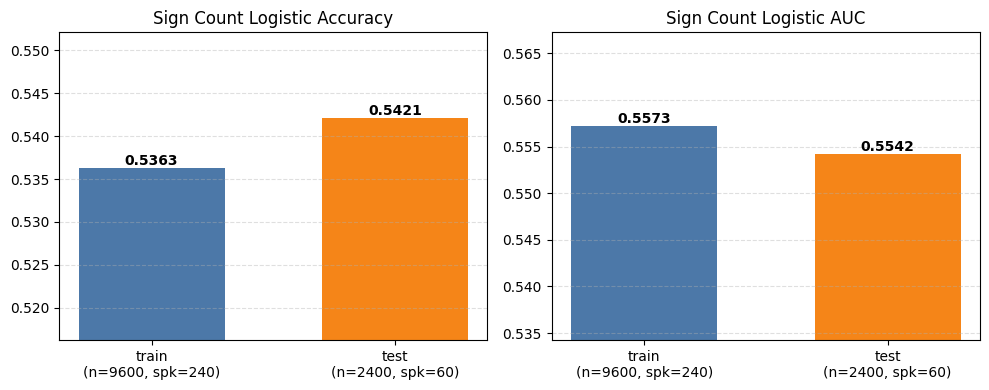

In [6]:
summary_df = pd.DataFrame([
    {
        'split': 'train',
        'accuracy': summary['train_accuracy'],
        'auc': summary['train_auc'],
        'rows': summary['train_rows'],
        'speakers': summary['train_speakers'],
    },
    {
        'split': 'test',
        'accuracy': summary['test_accuracy'],
        'auc': summary['test_auc'],
        'rows': summary['test_rows'],
        'speakers': summary['test_speakers'],
    },
])
display(summary_df)

plot_df = summary_df.copy()
plot_df['label'] = plot_df.apply(lambda r: f"{r['split']}\n(n={int(r['rows'])}, spk={int(r['speakers'])})", axis=1)

metrics = [('accuracy', 'Accuracy'), ('auc', 'AUC')]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (metric, title) in zip(axes, metrics):
    vals = plot_df[metric].astype(float).to_numpy()
    labels = plot_df['label'].tolist()
    ymin = max(0.0, vals.min() - 0.02)
    ymax = min(1.0, vals.max() + 0.01)
    if ymax - ymin < 0.02:
        ymin = max(0.0, vals.min() - 0.01)
        ymax = min(1.0, vals.max() + 0.01)
    bars = ax.bar(labels, vals, color=['#4C78A8', '#F58518'], width=0.6)
    ax.set_title(f'Sign Count Logistic {title}')
    ax.set_ylim(ymin, ymax)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [7]:
coef_df = pd.DataFrame({
    'concept': feature_cols,
    'coef': clf.coef_[0],
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)

print('Intercept:', float(clf.intercept_[0]))
display(coef_df)
display(coef_df.head(10))


Intercept: 0.0007728266827210538


,concept,coef,abs_coef
0,long_rising_steep_thick,0.181952,0.181952
1,long_dropping_steep_thin,0.147694,0.147694
2,short_constant_thick,-0.110777,0.110777
3,long_rising_steep_thin,-0.102837,0.102837
4,short_rising_steep_thin,0.102309,0.102309
5,long_dropping_steep_thick,0.091973,0.091973
6,short_rising_steep_thick,-0.066247,0.066247
7,short_dropping_steep_thick,-0.058586,0.058586
8,long_dropping_flat_thick,-0.049068,0.049068
9,long_constant_thick,0.043515,0.043515


,concept,coef,abs_coef
0,long_rising_steep_thick,0.181952,0.181952
1,long_dropping_steep_thin,0.147694,0.147694
2,short_constant_thick,-0.110777,0.110777
3,long_rising_steep_thin,-0.102837,0.102837
4,short_rising_steep_thin,0.102309,0.102309
5,long_dropping_steep_thick,0.091973,0.091973
6,short_rising_steep_thick,-0.066247,0.066247
7,short_dropping_steep_thick,-0.058586,0.058586
8,long_dropping_flat_thick,-0.049068,0.049068
9,long_constant_thick,0.043515,0.043515


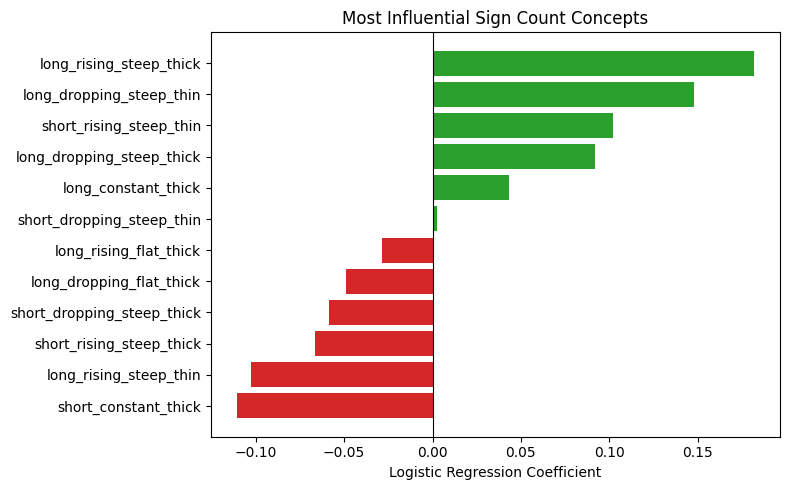

In [8]:
top_df = coef_df.head(12).copy().sort_values('coef')
plt.figure(figsize=(8, 5))
colors = ['#D62728' if v < 0 else '#2CA02C' for v in top_df['coef']]
plt.barh(top_df['concept'], top_df['coef'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Most Influential Sign Count Concepts')
plt.xlabel('Logistic Regression Coefficient')
plt.tight_layout()
plt.show()


In [9]:
with open(MODEL_OUT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(MODEL_OUT_DIR / 'logistic_regression.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open(MODEL_OUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

coef_df.to_csv(MODEL_OUT_DIR / 'coefficients.csv', index=False)
train_df.to_csv(MODEL_OUT_DIR / 'train_split.csv', index=False)
test_df.to_csv(MODEL_OUT_DIR / 'test_split.csv', index=False)

pred_train = train_df[meta_cols].copy()
pred_train['p_spoof'] = p_tr
pred_train['y_hat'] = yhat_tr
pred_train['split_role'] = 'train'

pred_test = test_df[meta_cols].copy()
pred_test['p_spoof'] = p_te
pred_test['y_hat'] = yhat_te
pred_test['split_role'] = 'test'

pred_df = pd.concat([pred_train, pred_test], axis=0, ignore_index=True)
pred_df.to_csv(MODEL_OUT_DIR / 'predictions.csv', index=False)
split_check_df.to_csv(MODEL_OUT_DIR / 'split_check.csv', index=False)

print('Saved outputs to:', MODEL_OUT_DIR)


Saved outputs to: /home/SpeakerRec/BioVoice/resnet_293/tcav/captum_tcav/asvspoof5/output/subset_20spk_20utts_per_spk_one_logistic_head/sign_count_logistic_results


## Extra Analysis

These cells help inspect which systems are easy or hard, where the model makes its biggest mistakes, and which concepts differ most between spoof and bonafide per system.


In [10]:
test_analysis_df = pred_df[pred_df['split_role'] == 'test'].copy()
test_analysis_df['is_correct'] = (test_analysis_df['binary_label'] == test_analysis_df['y_hat']).astype(int)
test_analysis_df['error_type'] = 'correct'
test_analysis_df.loc[(test_analysis_df['binary_label'] == 0) & (test_analysis_df['y_hat'] == 1), 'error_type'] = 'false_positive'
test_analysis_df.loc[(test_analysis_df['binary_label'] == 1) & (test_analysis_df['y_hat'] == 0), 'error_type'] = 'false_negative'

system_metrics = []
for system_id, sub in test_analysis_df.groupby('system_id'):
    y_true_sys = sub['binary_label'].to_numpy()
    y_hat_sys = sub['y_hat'].to_numpy()
    p_sys = sub['p_spoof'].to_numpy()
    tn, fp, fn, tp = confusion_matrix(y_true_sys, y_hat_sys).ravel()
    system_metrics.append({
        'system_id': system_id,
        'rows': int(len(sub)),
        'accuracy': float(accuracy_score(y_true_sys, y_hat_sys)),
        'auc': float(roc_auc_score(y_true_sys, p_sys)),
        'bonafide_rows': int((sub['binary_label'] == 0).sum()),
        'spoof_rows': int((sub['binary_label'] == 1).sum()),
        'true_negative': int(tn),
        'false_positive': int(fp),
        'false_negative': int(fn),
        'true_positive': int(tp),
        'fpr': float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        'fnr': float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    })

system_metrics_df = pd.DataFrame(system_metrics).sort_values(['accuracy', 'auc'], ascending=[False, False]).reset_index(drop=True)
display(system_metrics_df)


,system_id,rows,accuracy,auc,bonafide_rows,spoof_rows,true_negative,false_positive,false_negative,true_positive,fpr,fnr
0,A14,160,0.68125,0.724297,80,80,69,11,40,40,0.1375,0.5000
1,A03,160,0.66250,0.645078,80,80,66,14,40,40,0.1750,0.5000
2,A06,160,0.57500,0.549687,80,80,64,16,52,28,0.2000,0.6500
3,A05,160,0.57500,0.545000,80,80,59,21,47,33,0.2625,0.5875
4,A09,160,0.55625,0.567422,80,80,66,14,57,23,0.1750,0.7125
5,A08,160,0.54375,0.522188,80,80,59,21,52,28,0.2625,0.6500
6,A07,160,0.53750,0.542109,80,80,57,23,51,29,0.2875,0.6375
7,A02,160,0.51875,0.563203,80,80,60,20,57,23,0.2500,0.7125
8,A10,160,0.51250,0.545781,80,80,61,19,59,21,0.2375,0.7375
9,A13,160,0.51250,0.545703,80,80,65,15,63,17,0.1875,0.7875


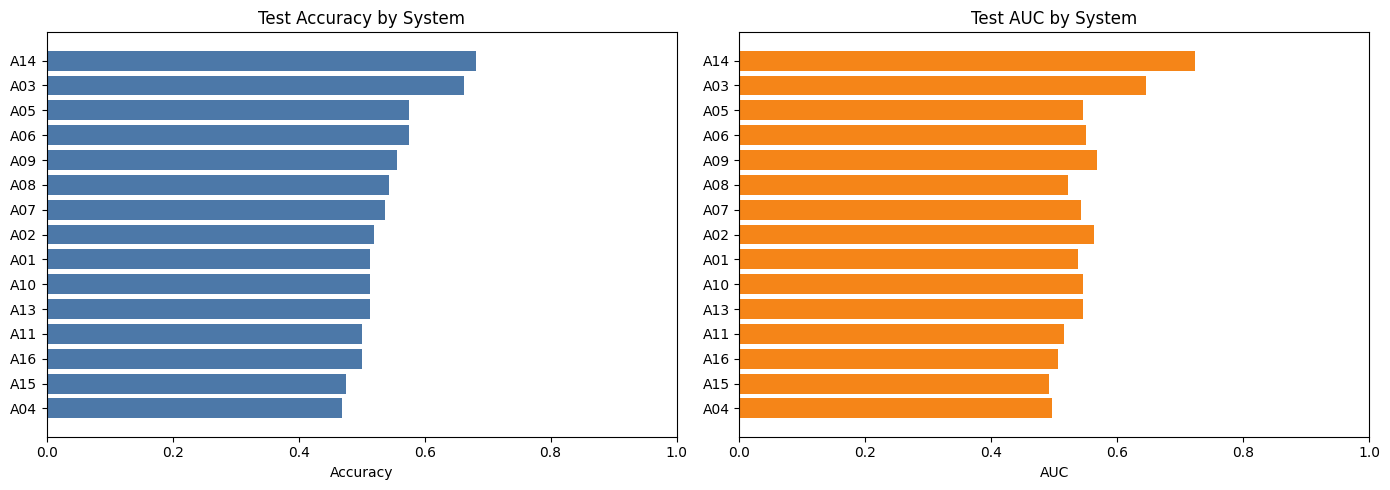

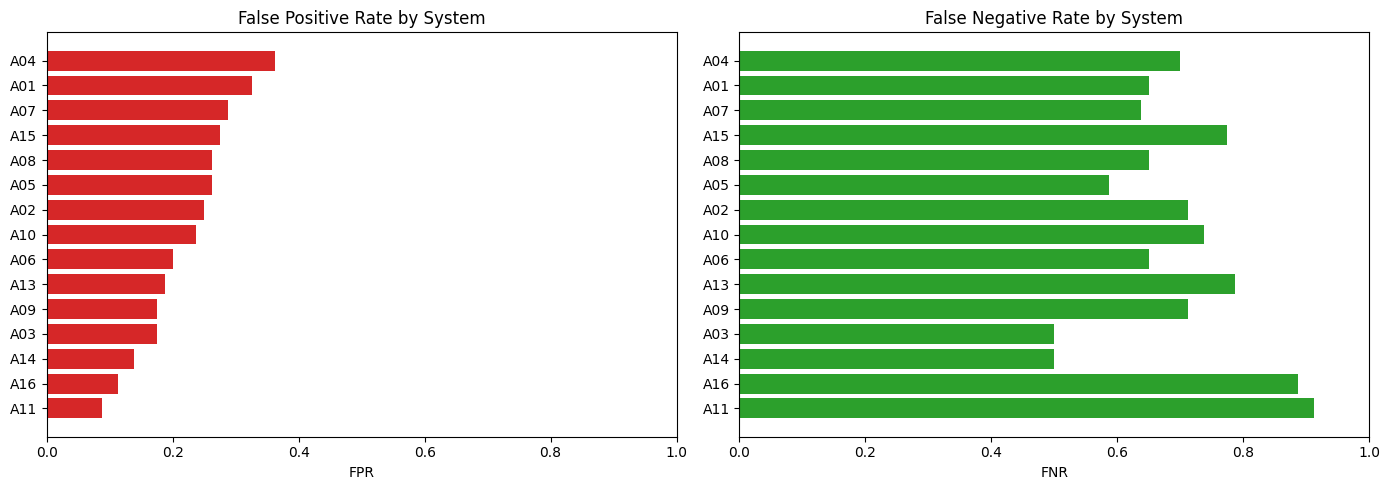

In [11]:
plot_df = system_metrics_df.sort_values('accuracy').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(plot_df['system_id'], plot_df['accuracy'], color='#4C78A8')
axes[0].set_title('Test Accuracy by System')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Accuracy')

axes[1].barh(plot_df['system_id'], plot_df['auc'], color='#F58518')
axes[1].set_title('Test AUC by System')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('AUC')
plt.tight_layout()
plt.show()

err_df = system_metrics_df.sort_values('fpr').reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(err_df['system_id'], err_df['fpr'], color='#D62728')
axes[0].set_title('False Positive Rate by System')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('FPR')

axes[1].barh(err_df['system_id'], err_df['fnr'], color='#2CA02C')
axes[1].set_title('False Negative Rate by System')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('FNR')
plt.tight_layout()
plt.show()


In [12]:
false_pos_df = test_analysis_df[test_analysis_df['error_type'] == 'false_positive'].copy()
false_pos_df['confidence'] = false_pos_df['p_spoof']
false_pos_df = false_pos_df.sort_values('confidence', ascending=False)

false_neg_df = test_analysis_df[test_analysis_df['error_type'] == 'false_negative'].copy()
false_neg_df['confidence'] = 1.0 - false_neg_df['p_spoof']
false_neg_df = false_neg_df.sort_values('confidence', ascending=False)

print('Most confident false positives:')
display(false_pos_df[['system_id', 'speaker_id', 'utt_id', 'target_class', 'binary_label', 'p_spoof', 'y_hat']].head(20))

print('Most confident false negatives:')
display(false_neg_df[['system_id', 'speaker_id', 'utt_id', 'target_class', 'binary_label', 'p_spoof', 'y_hat']].head(20))


Most confident false positives:


,system_id,speaker_id,utt_id,target_class,binary_label,p_spoof,y_hat
10790,A08,T_5257,T_0000065012,bonafide,0,0.726592,1
9823,A02,T_4913,T_0000068164,bonafide,0,0.706539,1
10143,A04,T_4913,T_0000068164,bonafide,0,0.706539,1
11758,A15,D_4888,D_0002903293,bonafide,0,0.688527,1
11918,A16,D_4888,D_0002903293,bonafide,0,0.688527,1
9661,A01,T_4519,T_0000009360,bonafide,0,0.676777,1
9978,A03,T_3850,T_0000177393,bonafide,0,0.671961,1
10420,A06,T_1799,T_0000001213,bonafide,0,0.668952,1
10720,A08,T_2182,T_0000007195,bonafide,0,0.668952,1
9611,A01,T_2284,T_0000082259,bonafide,0,0.667674,1


Most confident false negatives:


,system_id,speaker_id,utt_id,target_class,binary_label,p_spoof,y_hat
10367,A05,T_4184,T_0000067146,spoof,1,0.331913,0
11921,A16,D_0430,D_0000407254,spoof,1,0.341080,0
11819,A15,D_2991,D_0002318275,spoof,1,0.347112,0
11998,A16,D_4888,D_0002621410,spoof,1,0.347562,0
10856,A08,T_3725,T_0000153900,spoof,1,0.351704,0
11829,A15,D_4888,D_0002020306,spoof,1,0.356931,0
10805,A08,T_2182,T_0000073771,spoof,1,0.360721,0
11929,A16,D_0430,D_0001060438,spoof,1,0.362052,0
10359,A05,T_3702,T_0000149157,spoof,1,0.362474,0
11191,A10,D_4057,D_0002098279,spoof,1,0.364185,0


,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin
A01,-0.1125,0.0625,-0.0375,0.0000,-0.0250,0.0625,0.0125,-0.0500,0.0375,0.0375,-0.1375,0.0375
A02,-0.0750,-0.0250,0.0375,0.0250,0.0500,0.0125,-0.0875,-0.0375,0.0000,-0.0125,-0.0125,0.0375
A03,0.3250,0.2375,0.3000,0.2500,0.2875,0.3125,0.2000,0.3000,0.3250,0.1875,0.3125,0.3250
A04,-0.0875,-0.1000,-0.0750,-0.1125,-0.1375,-0.0750,-0.1500,-0.1250,-0.0500,-0.1000,-0.1625,-0.1125
A05,0.1000,0.0375,0.0500,0.1250,0.0125,0.1250,0.0000,0.1500,0.1375,0.0375,0.0875,0.1125
A06,0.1625,0.1250,0.1750,0.0750,0.0750,0.1250,0.0875,0.1500,0.0500,0.0375,0.2125,0.1500
A07,0.0500,0.1500,0.1500,0.0750,0.0000,0.0250,0.0000,0.0000,0.2000,0.0750,0.1000,0.1625
A08,0.1125,0.0875,0.0625,0.0250,-0.0125,0.0500,0.0500,0.0625,0.0875,0.0750,0.1000,0.0625
A09,0.1125,0.0500,0.1000,0.0000,0.0250,0.0750,0.0250,0.0000,-0.0125,0.0125,0.0875,0.0875
A10,0.0500,0.0250,0.0125,0.0125,-0.0625,0.0500,0.0250,-0.0750,0.0125,0.0000,0.0375,-0.0125


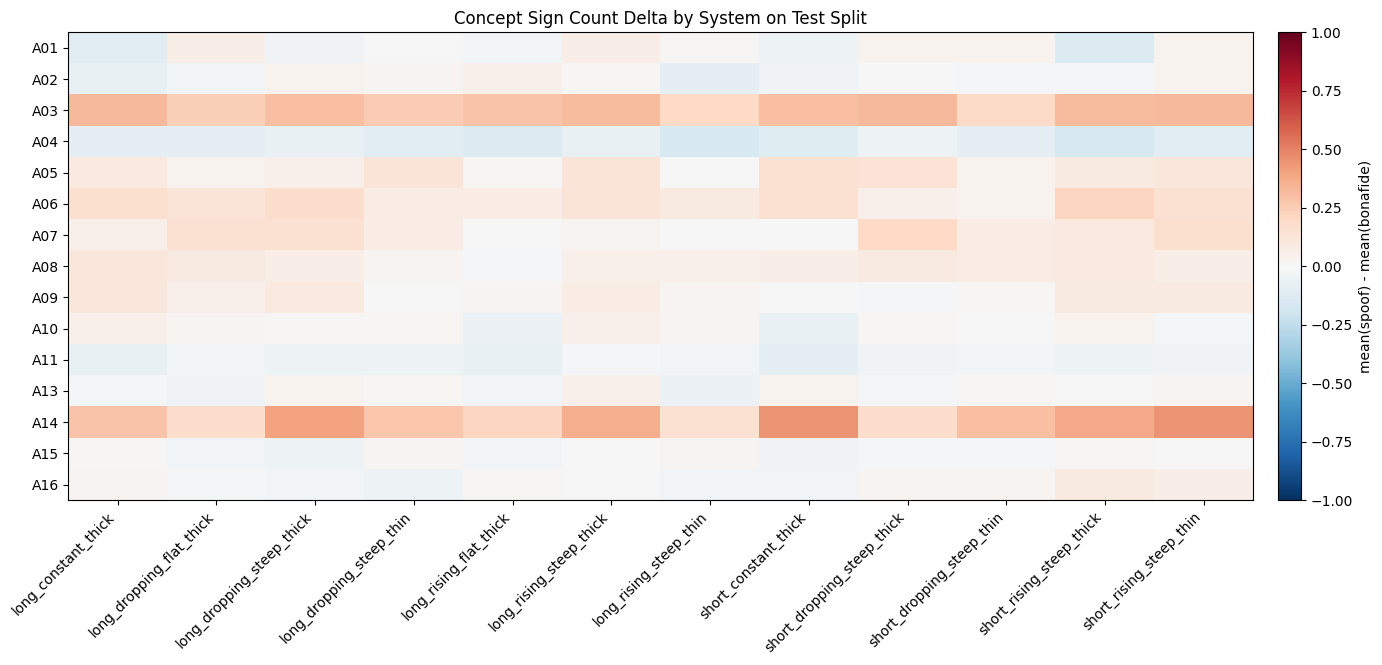

In [13]:
delta_rows = []
for system_id, sub in test_df.groupby('system_id'):
    spoof_mean = sub.loc[sub['binary_label'] == 1, feature_cols].mean()
    bonafide_mean = sub.loc[sub['binary_label'] == 0, feature_cols].mean()
    delta_rows.append((system_id, (spoof_mean - bonafide_mean).to_dict()))

system_delta_df = pd.DataFrame({system_id: vals for system_id, vals in delta_rows}).T[feature_cols]
display(system_delta_df)

plt.figure(figsize=(14, max(5, len(system_delta_df) * 0.45)))
im = plt.imshow(system_delta_df.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.02, pad=0.02, label='mean(spoof) - mean(bonafide)')
plt.yticks(range(len(system_delta_df.index)), system_delta_df.index)
plt.xticks(range(len(system_delta_df.columns)), system_delta_df.columns, rotation=45, ha='right')
plt.title('Concept Sign Count Delta by System on Test Split')
plt.tight_layout()
plt.show()
